# Optimise model (nested CV)

Run grid search with cross-validation for hyperparameter optimisation.
For each outer fold, run inner CV grid search on the outer training set.

In [1]:
run = "k"

In [2]:
import sys
sys.path.append("../../../src/ml")

In [3]:
!pwd

/home/sgrant/mu2e-cosmic/notebooks/ml/xgboost


In [4]:
from assemble import AssembleDataset
assembler = AssembleDataset(run=run, cutset_name="MLPreprocess", verbosity=2)
data = assembler.assemble_dataset(n_outer_folds=5)

[LoadML] [OK] Initialised
[Load] [OK] Initialised with out_path=/home/sgrant/mu2e-cosmic/output/ml/k/data/CRY_onspill-LH_aw
[Load] [OK] Successfully loaded results from /home/sgrant/mu2e-cosmic/output/ml/k/data/CRY_onspill-LH_aw/results.pkl
[Load] [OK] Initialised with out_path=/home/sgrant/mu2e-cosmic/output/ml/k/data/CE_mix2BB_onspill-LH_aw
[Load] [OK] Successfully loaded results from /home/sgrant/mu2e-cosmic/output/ml/k/data/CE_mix2BB_onspill-LH_aw/results.pkl
[LoadML] [OK] Got full results
[Assemble] [OK] Loaded data
[Assemble] [OK] Initialised
[Assemble] [DEBUG] Got sorted and labelled DataFrames
[Assemble] [DEBUG] Got combined dataset
[Assemble] [DEBUG] Columns: Index(['event', 'subrun', 'crv_x', 'crv_y', 'crv_z', 'PEs', 'dT', 'nHits',
       'nLayers', 'angle', 'timeStart', 'timeEnd', 'sector', 'PEs_per_hit',
       't0', 'd0', 'tanDip', 'maxr', 'mom_mag', 'label'],
      dtype='str')
[Assemble] [OK] Prepared 5-fold nested CV (event-level grouping)
  Total: 2163528 coincidences


In [5]:
from optimise import Optimise

param_grid = {
    "n_estimators": [100, 200, 500, 1000],
    "max_depth": [3, 5, 7, 9],
    "learning_rate": [0.05, 0.1, 0.3],
}
fixed_params = {"device": "cuda", "tree_method": "hist"}

# Nested CV: run inner CV grid search on each outer fold's training set
outer_best_hps = []
for k, (train_idx, test_idx) in enumerate(data["outer_folds"]):
    print(f"\n{'='*60}")
    print(f"Outer fold {k}")
    print(f"{'='*60}")
    fold_data = AssembleDataset.get_fold_data(data, train_idx, test_idx)
    opt = Optimise(fold_data, run=run, min_efficiency=0.999, scale_features=False)
    best = opt.grid_search_cv(param_grid, n_folds=5, fixed_params=fixed_params)
    outer_best_hps.append(best["hyperparams"])
    print(f"Fold {k} best: {best['hyperparams']}, deadtime: {best['mean_deadtime']*100:.3f}%")


Outer fold 0
[Optimise] [OK] Initialised
[Optimise] [INFO] CV grid search: 48 combinations x 5 folds = 240 fits over ['n_estimators', 'max_depth', 'learning_rate']
[Optimise] [INFO] [1/48] scan_cv_000: deadtime=7.487±3.384%, veto_eff=99.907%, overfit_gap=0.00003
[Optimise] [INFO] [2/48] scan_cv_001: deadtime=0.805±0.329%, veto_eff=99.907%, overfit_gap=0.00004
[Optimise] [INFO] [3/48] scan_cv_002: deadtime=0.195±0.093%, veto_eff=99.907%, overfit_gap=0.00008
[Optimise] [INFO] [4/48] scan_cv_003: deadtime=4.465±5.710%, veto_eff=99.907%, overfit_gap=0.00032
[Optimise] [INFO] [5/48] scan_cv_004: deadtime=0.439±0.235%, veto_eff=99.907%, overfit_gap=0.00005
[Optimise] [INFO] [6/48] scan_cv_005: deadtime=0.124±0.059%, veto_eff=99.907%, overfit_gap=0.00007
[Optimise] [INFO] [7/48] scan_cv_006: deadtime=2.243±2.504%, veto_eff=99.907%, overfit_gap=0.00032
[Optimise] [INFO] [8/48] scan_cv_007: deadtime=0.391±0.385%, veto_eff=99.907%, overfit_gap=0.00007
[Optimise] [INFO] [9/48] scan_cv_008: deadt

In [6]:
import pandas as pd
from collections import Counter

# Summarise best HPs across outer folds
print("Best hyperparameters per outer fold:")
for k, hp in enumerate(outer_best_hps):
    print(f"  Fold {k}: {hp}")

# Check consistency
hp_tuples = [tuple(sorted(hp.items())) for hp in outer_best_hps]
hp_counts = Counter(hp_tuples)
print(f"\nMost common: {dict(hp_counts.most_common(1)[0][0])} ({hp_counts.most_common(1)[0][1]}/{len(outer_best_hps)} folds)")

# Use the most common HP set as the consensus
consensus_hp = dict(hp_counts.most_common(1)[0][0])
print(f"\nConsensus best HP: {consensus_hp}")

Best hyperparameters per outer fold:
  Fold 0: {'n_estimators': 1000, 'max_depth': 3, 'learning_rate': 0.1}
  Fold 1: {'n_estimators': 1000, 'max_depth': 3, 'learning_rate': 0.1}
  Fold 2: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.3}
  Fold 3: {'n_estimators': 1000, 'max_depth': 3, 'learning_rate': 0.1}
  Fold 4: {'n_estimators': 1000, 'max_depth': 3, 'learning_rate': 0.1}

Most common: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 1000} (4/5 folds)

Consensus best HP: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 1000}


[Optimise] [OK] Saved to /home/sgrant/mu2e-cosmic/output/images/ml/k/optimise/overfit_max_depth.png


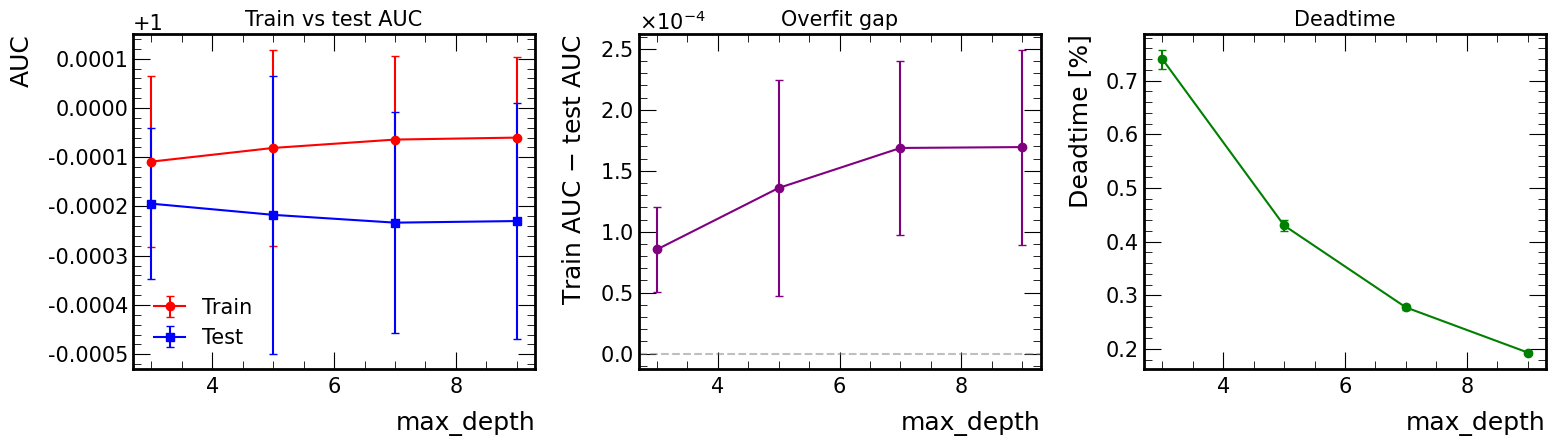

[Optimise] [OK] Saved to /home/sgrant/mu2e-cosmic/output/images/ml/k/optimise/overfit_n_estimators.png


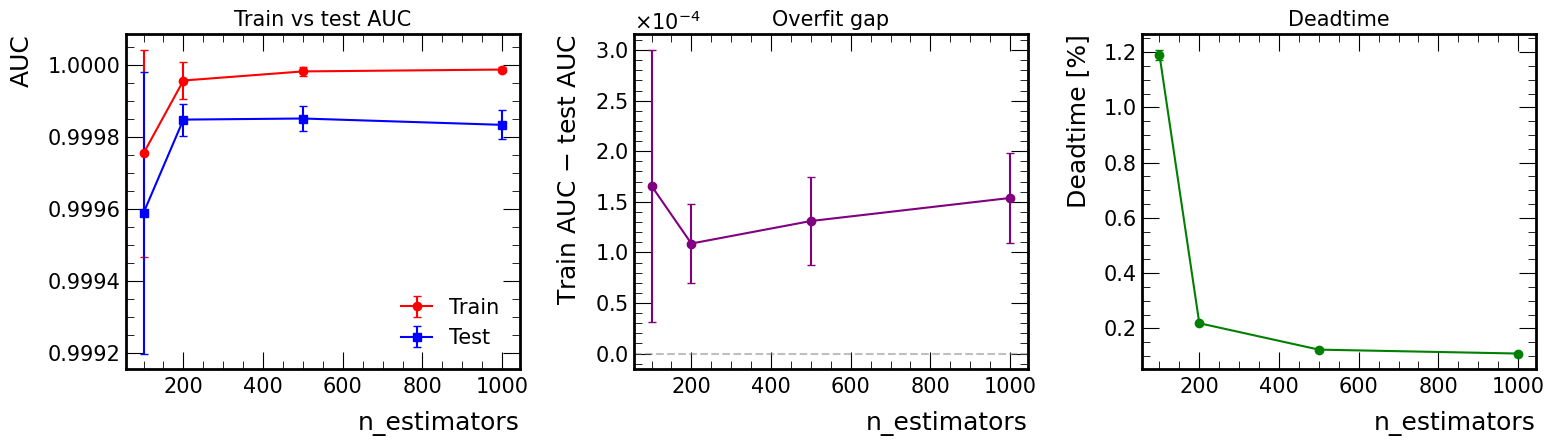

[Optimise] [OK] Saved to /home/sgrant/mu2e-cosmic/output/images/ml/k/optimise/overfit_learning_rate.png


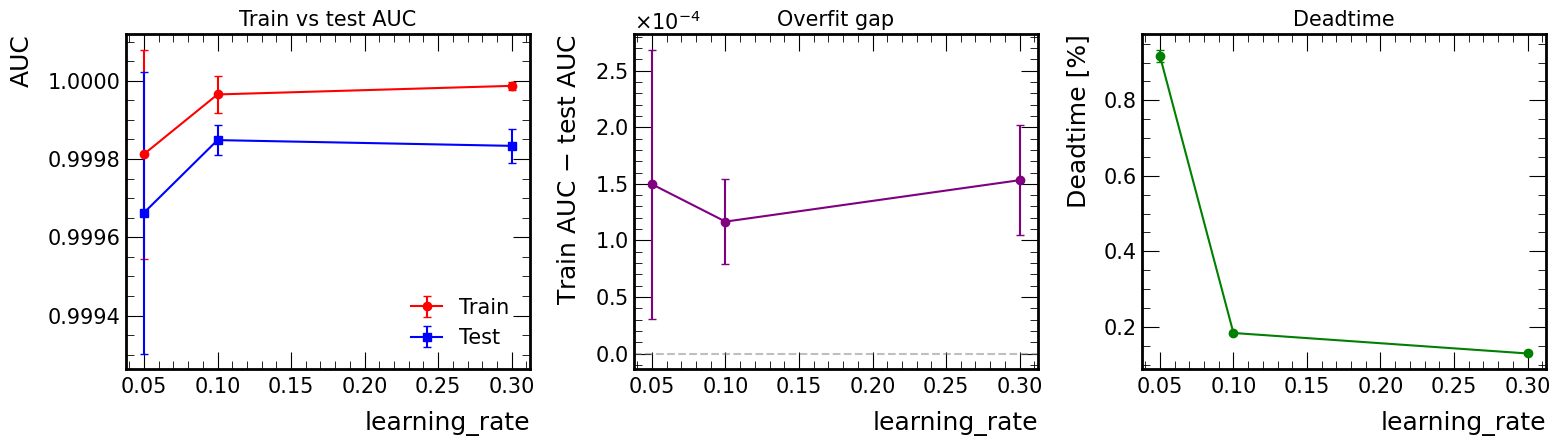

[Optimise] [OK] Summary saved to /home/sgrant/mu2e-cosmic/output/ml/k/results/optimisation_summary_nested_cv.csv


In [7]:
# The last opt instance still has its summary from the final outer fold
# For a full picture, run the diagnostic plots on the last fold as a representative example
opt.plot_overfit_diagnostic("max_depth")
opt.plot_overfit_diagnostic("n_estimators")
opt.plot_overfit_diagnostic("learning_rate")
opt.save_summary(tag="nested_cv")

[Optimise] [OK] Initialised
[Optimise] [INFO] CV grid search: 4 combinations x 5 folds = 20 fits over ['n_estimators', 'max_depth', 'learning_rate']
[Optimise] [INFO] [1/4] scan_cv_000: deadtime=0.106±0.036%, veto_eff=99.907%, overfit_gap=0.00007
[Optimise] [INFO] [2/4] scan_cv_001: deadtime=0.094±0.042%, veto_eff=99.907%, overfit_gap=0.00009
[Optimise] [INFO] [3/4] scan_cv_002: deadtime=0.091±0.045%, veto_eff=99.907%, overfit_gap=0.00011
[Optimise] [INFO] [4/4] scan_cv_003: deadtime=0.097±0.057%, veto_eff=99.907%, overfit_gap=0.00012
[Optimise] [OK] CV grid search complete. Best: scan_cv_002 (deadtime: 0.091%, veto eff: 99.907%)
[Optimise] [OK] Saved to /home/sgrant/mu2e-cosmic/output/images/ml/k/optimise/overfit_n_estimators.png


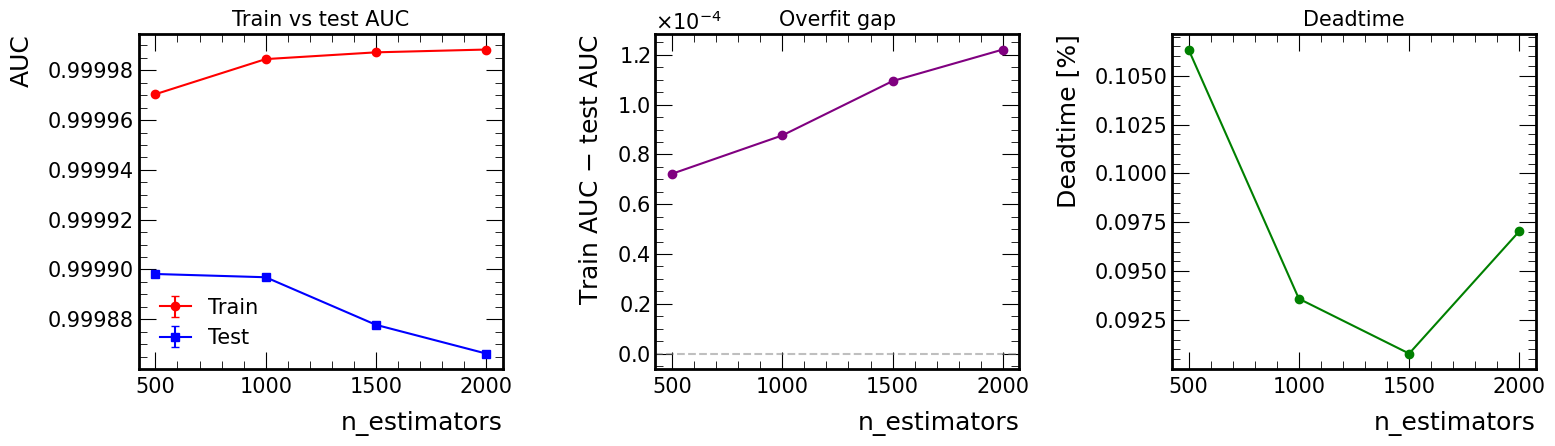

In [8]:
# Extend n_estimators to check we've found the plateau
param_grid_ext = {
    "n_estimators": [500, 1000, 1500, 2000],
    "max_depth": [3],
    "learning_rate": [0.1],
}

train_idx, test_idx = data["outer_folds"][0]
fold_data = AssembleDataset.get_fold_data(data, train_idx, test_idx)
opt_ext = Optimise(fold_data, run=run, min_efficiency=0.999, scale_features=False)
best_ext = opt_ext.grid_search_cv(param_grid_ext, n_folds=5, fixed_params=fixed_params)
opt_ext.plot_overfit_diagnostic("n_estimators")


## Analysis

Check whether the consensus best HP is consistent across outer folds. If all folds agree, the optimisation is robust. If they disagree, the landscape is flat and the choice doesn't matter much. Best way is to pick the simplest model.

## Class imbalance 

In [9]:
data["y"].value_counts()

label
0    2139801
1      23727
Name: count, dtype: int64

In [10]:
param_grid_spw = {
    "scale_pos_weight": [1, 10, 50, 90],
}
fixed_params_spw = {**consensus_hp, "device": "cuda", "tree_method": "hist"}

# Use a single outer fold for the SPW scan (it doesn't affect ranking)
train_idx, test_idx = data["outer_folds"][0]
fold_data = AssembleDataset.get_fold_data(data, train_idx, test_idx)
opt_spw = Optimise(fold_data, run=run, min_efficiency=0.999, scale_features=False)
best_spw = opt_spw.grid_search_cv(param_grid_spw, n_folds=5, fixed_params=fixed_params_spw)

[Optimise] [OK] Initialised
[Optimise] [INFO] CV grid search: 4 combinations x 5 folds = 20 fits over ['scale_pos_weight']
[Optimise] [INFO] [1/4] scan_cv_000: deadtime=0.094±0.042%, veto_eff=99.907%, overfit_gap=0.00009
[Optimise] [INFO] [2/4] scan_cv_001: deadtime=0.107±0.071%, veto_eff=99.907%, overfit_gap=0.00009
[Optimise] [INFO] [3/4] scan_cv_002: deadtime=0.094±0.035%, veto_eff=99.907%, overfit_gap=0.00013
[Optimise] [INFO] [4/4] scan_cv_003: deadtime=0.108±0.042%, veto_eff=99.907%, overfit_gap=0.00012
[Optimise] [OK] CV grid search complete. Best: scan_cv_000 (deadtime: 0.094%, veto eff: 99.907%)


[Optimise] [OK] Saved to /home/sgrant/mu2e-cosmic/output/images/ml/k/optimise/overfit_scale_pos_weight.png


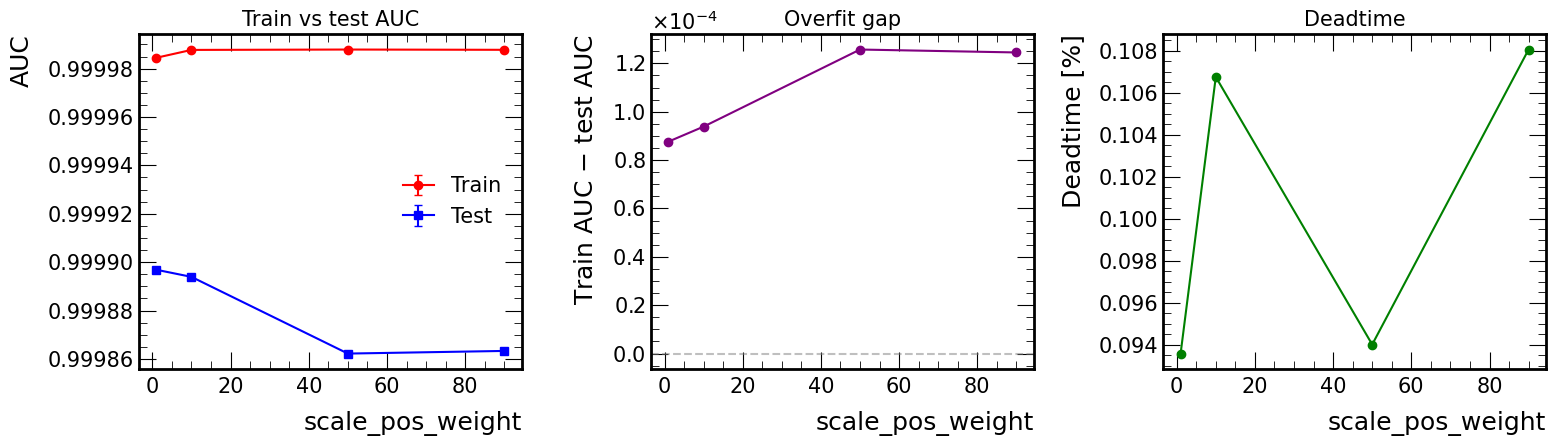

In [11]:
opt_spw.plot_overfit_diagnostic("scale_pos_weight")

In [15]:
opt_spw.get_summary()

,tag,scale_pos_weight,train_auc,test_auc,overfit_gap,threshold,veto_efficiency,veto_efficiency_std,deadtime,deadtime_std,signal_efficiency
0,scan_cv_000,1,0.999984,0.999897,0.000088,0.199340,0.999068,0.000009,0.000936,0.000425,0.999064
1,scan_cv_002,50,0.999988,0.999862,0.000126,0.650185,0.999068,0.000009,0.000940,0.000346,0.999060
2,scan_cv_001,10,0.999988,0.999894,0.000094,0.437644,0.999068,0.000009,0.001068,0.000709,0.998932
3,scan_cv_003,90,0.999988,0.999863,0.000124,0.683228,0.999068,0.000009,0.001081,0.000420,0.998919


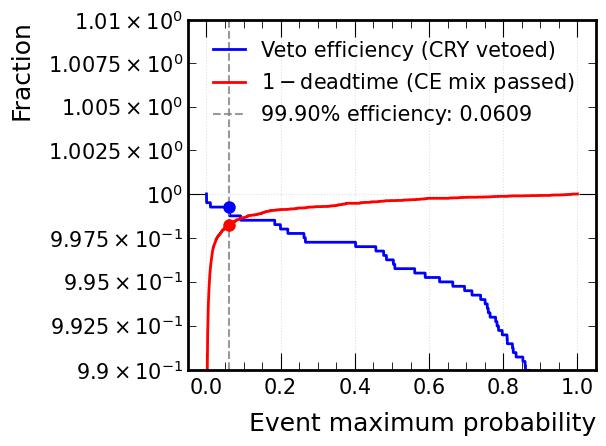

{'threshold': 0.06090609060906091,
 'veto_efficiency': 0.9992477432296891,
 'deadtime': 0.0017631349230357034,
 'signal_efficiency': 0.9982368650769643,
 'precision': 0.9513010264979709,
 'recall': 0.9992477432296891,
 'f1': 0.9746850923321512,
 'thresholds': array([0.00000000e+00, 1.00010001e-04, 2.00020002e-04, ...,
        9.99799980e-01, 9.99899990e-01, 1.00000000e+00]),
 'veto_efficiencies': array([1.        , 0.99974925, 0.99974925, ..., 0.39117352, 0.25952859,
        0.        ]),
 'signal_efficiencies': array([0.        , 0.95352757, 0.96665601, ..., 1.        , 1.        ,
        1.        ])}

In [16]:
from train import Train
from validate import Validate

scale_pos_weight = 1 

hp = {**consensus_hp, "scale_pos_weight": scale_pos_weight}

# Train on first outer fold to check score distribution
train_idx, test_idx = data["outer_folds"][0]
fold_data = AssembleDataset.get_fold_data(data, train_idx, test_idx)

trn = Train(fold_data, run=run, verbosity=0)
results = trn.train(tag="spw_check", save_output=False, **hp)

val = Validate(results, run=run, verbosity=0)
val.roc_auc()
val.find_threshold(min_eff=0.999, plot=True, show=True)

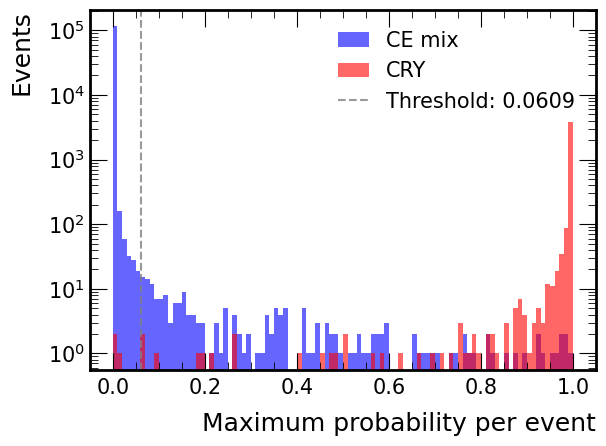

In [17]:
thr = val.find_threshold(min_eff=0.999, plot=False, show=False)
val.plot_score_distribution(threshold=thr["threshold"])